# 6.6 Q2: Diabetes Prediction

**Objective:** Predict diabetes using medical features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import os

# Use THIS notebook's folder paths
NOTEBOOK_DIR = os.getcwd()
DATASETS_DIR = os.path.join(NOTEBOOK_DIR, 'datasets')
OUTPUTS_DIR = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [2]:
# Load Data
df = pd.read_csv(os.path.join(DATASETS_DIR, 'diabetes.csv'))
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (768, 9)
Columns: ['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi', 'diabetespedigree', 'age', 'outcome']
   pregnancies  glucose  bloodpressure  skinthickness  insulin   bmi  \
0            6      129             71             15      202  38.8   
1           14      113             70             29        3  17.3   
2           10      144             75             11       27  40.1   
3            7       53             84             17       18  41.7   
4            6      127             81             20       21  29.9   

   diabetespedigree  age  outcome  
0             0.119   55        1  
1             0.330   29        0  
2             0.142   55        0  
3             0.080   31        1  
4             0.491   64        1  


In [3]:
# Train Model
X = df.drop('outcome', axis=1).values
y = df['outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Accuracy: 0.6818

Confusion Matrix:
[[105   2]
 [ 47   0]]


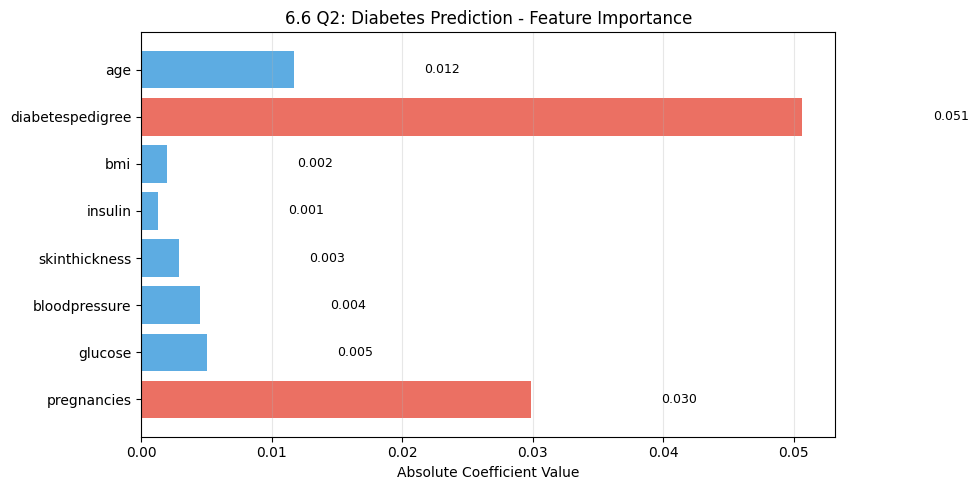

✅ Saved to: /home/z/my-project/ML-Labs-1-2-Final/02-Logistic-Regression/outputs/6.6_Q2_Diabetes_Prediction.png


In [4]:
# Feature Importance - Save to outputs/
features = df.columns[:-1]
importance = abs(model.coef_[0])

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if imp > importance.mean() else '#3498db' for imp in importance]
bars = plt.barh(features, importance, color=colors, alpha=0.8)
plt.xlabel('Absolute Coefficient Value')
plt.title('6.6 Q2: Diabetes Prediction - Feature Importance')
plt.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, importance):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '6.6_Q2_Diabetes_Prediction.png'), dpi=120)
plt.show()
print(f"✅ Saved to: {OUTPUTS_DIR}/6.6_Q2_Diabetes_Prediction.png")